In [1]:
# Importation de NumPy pour les calculs numériques
import numpy as np

# Importation de Matplotlib pour les graphes
import matplotlib.pyplot as plt


In [2]:
# Sous-ensemble reel de paires de traduction anglais-francais
# Source : corpus Tatoeba (via github.com/L1aoXingyu/seq2seq-translation), filtre et sous-echantillonne
TRANSLATION_PAIRS = [
    ('she is habitually late .', 'elle est habituellement en retard .'),
    ('he is not an american .', "il n'est pas americain ."),
    ('she is her friend .', 'elle est son amie .'),
    ('you are a good cook .', 'tu es bon cuisinier .'),
    ('i am too short .', 'je suis trop petit .'),
    ('they are making a salad .', 'ils font une salade .'),
    ('you are a bad person .', 'vous etes un etre mauvais .'),
    ('i am tired .', 'je suis fatigue !'),
    ('they are not tired .', 'elles ne sont pas fatiguees .'),
    ('he is playing music .', 'il joue de la musique .'),
    ('they are great friends .', 'elles sont de grandes amies .'),
    ('he is a harsh critic .', "c'est un critique acerbe ."),
    ('they are my friends .', 'ce sont mes amis .'),
    ('we are watching .', 'nous regardons .'),
    ('he is very good looking .', 'il est tres seduisant .'),
    ('i am very pleased .', 'je suis tres satisfait .'),
    ('you are blushing .', 'tu rougis !'),
    ('he is absent from school .', "il est absent de l'ecole ."),
    ('we are good friends .', 'nous sommes bons amis .'),
    ('he is unmarried .', "il n'est pas marie ."),
    ('you are fabulous .', 'tu es fabuleux .'),
    ('i am very pleased .', 'je suis tres content .'),
    ('he is only a child .', "il n'est qu'un enfant ."),
    ('he is walking very slowly .', 'il marche tres lentement .'),
    ('i am at home .', 'je suis a la maison .'),
    ('you are not japanese .', "vous n'etes pas japonaise ."),
    ('he is ready to work .', 'il est pret a travailler .'),
    ('they are very kind .', 'ils sont tres bienveillants .'),
    ('you are the chosen one .', "vous etes l'elu ."),
    ('he is all but dead .', 'il est tout sauf mort .'),
    ('he is fluent in english .', 'il parle anglais couramment .'),
    ('he is likely to come .', 'il va probablement venir .'),
    ('he is very careful .', 'il est tres soigneux .'),
    ('you are the chosen one .', "tu es l'elu ."),
    ('it is too hot .', 'il fait trop chaud .'),
    ('he is a spoiled child .', "c'est un enfant gate ."),
    ('he is a daredevil .', "c'est un casse cou ."),
    ('i am on duty now .', 'je suis actuellement en service .'),
    ('he is selfish and greedy .', 'il est egoiste et cupide .'),
    ('you are not japanese .', "tu n'es pas japonaise ."),
    ('she is a gifted artist .', 'elle est une artiste nee .'),
    ('i am fond of music .', "j'adore la musique ."),
    ('she is not here yet .', "elle n'est pas encore la ."),
    ('we are classmates .', 'nous sommes camarades de classe .'),
    ('he is reading .', 'il lit .'),
    ('i am sorry for you .', 'je suis desole pour toi .'),
    ('i am a stranger here .', 'ici je suis un etranger .'),
    ("he isn't an american .", "il n'est pas americain ."),
    ('she is a wonderful wife .', "c'est une femme magnifique ."),
    ('you are big .', 'tu es grande .'),
    ('she is hostile to me .', "elle m'est hostile ."),
    ('they are very kind .', 'elles sont tres gentilles .'),
    ('he is wearing glasses .', 'il porte des lunettes .'),
    ('she is about my age .', 'elle a environ mon age .'),
    ('he is always neatly dressed .', 'il est toujours soigneusement vetu .'),
    ('i am afraid to go .', "j'ai peur de m'y rendre ."),
    ('she is a reliable person .', 'on peut compter sur elle .'),
    ('i am frying fish .', 'je fais frire du poisson .'),
    ('he is seeking employment .', 'il cherche un emploi .'),
    ("he isn't perfect .", "il n'est pas parfait ."),
    ('he is sharp witted .', "il a l'esprit vif ."),
    ('i am not kidding .', 'je ne blague pas .'),
    ('we are teachers .', 'nous sommes enseignants .'),
    ('she is not tall .', "elle n'est pas grande ."),
    ('you are a doctor .', 'vous etes medecin .'),
    ('you are so cute .', 'comme tu es mignonne .'),
    ('she is a wonderful woman .', "c'est une femme magnifique ."),
    ('you are very insensitive .', 'vous etes tres indelicats .'),
    ('it is of great value .', "c'est de grande valeur ."),
    ('he is late .', 'il est en retard .'),
    ('you are a good boy .', "t'es un bon garcon !"),
    ('you are overworked .', 'tu es surmene .'),
    ('she is a good swimmer .', 'elle est bonne nageuse .'),
    ('it is foggy .', 'il y a du brouillard .'),
    ('you are so stupid .', 'tu es tellement idiote !'),
    ('i am rather happy .', 'je suis assez content .'),
    ("it is pochi's food .", "c'est la nourriture de pochi ."),
    ('they are very cheerful .', 'elles sont fort joyeuses .'),
    ('he is incompetent .', 'il est incompetent .'),
    ('he is thirty years old .', 'il a trente ans .'),
    ('you are early .', 'vous etes matinal .'),
    ('i am very tall .', 'je suis tres grande .'),
    ('he is washing his car .', 'il lave sa voiture .'),
    ('you are so stupid .', 'tu es tellement idiot !'),
    ('it is a payday today .', "aujourd'hui c'est jour de paie ."),
    ('he is suspected of robbery .', 'il est suspecte de vol .'),
    ('i am going to sleep .', 'je vais dormir .'),
    ('he is a good carpenter .', 'il est bon charpentier .'),
    ("you aren't my mother .", "vous n'etes pas ma mere ."),
    ('he is boiling with rage .', 'il bout de colere .'),
    ('i m able to speak .', 'je suis capable de parler .'),
    ('she is a doctor .', 'elle est medecin .'),
    ('he is an actor .', "c'est un acteur ."),
    ("we aren't married .", 'nous ne sommes pas maries .'),
    ('he is an office worker .', "c'est un employe de bureau ."),
    ("you aren't looking .", 'vous ne regardez pas .'),
    ("you aren't tom .", "tu n'es pas tom ."),
    ('you are so childish sometimes .', 'tu es parfois si puerile .'),
    ('she is a poor cook .', "c'est une pietre cuisiniere ."),
    ('he is playing there .', 'il y joue .'),
    ('he is busy .', 'il a a faire .'),
    ('you are my daughter .', 'vous etes ma fille .'),
    ('you are the one .', 'tu es celui la .'),
    ('you are a good boy .', 'vous etes un bon garcon .'),
    ('you are big .', 'vous etes grand .'),
    ('you are good .', 'tu es bon .'),
    ('she is curt .', "elle n'a pas de charme ."),
    ('i am okay .', 'je vais bien .'),
    ('you are beautiful .', 'vous etes belles .'),
    ('it is under the chair .', 'il est sous la chaise .'),
    ('he is a big prankster .', "c'est un grand farceur ."),
    ('i am a professor .', 'je suis professeur .'),
    ('i am calm .', 'je suis calme .'),
    ('she is expecting a child .', 'elle attend un enfant .'),
    ('i am tired of homework .', 'je suis fatiguee des devoirs .'),
    ('they are reading her book .', 'elles lisent son livre .'),
    ('i am very tired .', 'je suis tres fatigue .'),
    ('we are teachers .', 'nous sommes enseignantes .'),
    ('it is almost three .', 'il est presque trois heures .'),
    ('i am better .', 'je suis mieux .'),
    ('i am in london .', 'je suis a londres .'),
    ('she is out of danger .', 'elle est hors de danger .'),
    ('you are seriously ill .', 'vous etes un grand malade .'),
    ("you aren't invited .", "vous n'etes pas invitees ."),
    ('he is very brave .', 'il est fort courageux .'),
    ('he is willing enough .', 'il a suffisamment de volonte .'),
    ('he is a born poet .', "c'est un poete ne ."),
    ('i am lazy .', 'je suis faineante .'),
    ('i am terribly hungry .', "j'ai terriblement faim ."),
    ('i am brushing my teeth .', 'je me brosse les dents .'),
    ('he is in pajamas .', 'il est en pyjama .'),
    ('you are a good person .', 'vous etes une chouette gonzesse .'),
    ('he is his own master .', 'il est son propre maitre .'),
    ('it is possible .', "c'est possible ."),
    ('i am exhausted .', 'je suis fourbu .'),
    ('he is always day dreaming .', 'il revasse toujours .'),
    ('he is crazy about skiing .', 'il est fou de ski .'),
    ('you are the one .', 'vous etes celle la .'),
    ('i am almost ready .', 'je suis quasiment prete .'),
    ('you are so stupid .', 'vous etes tellement idiots !'),
    ('they are five in all .', 'ils sont cinq en tout .'),
    ('they are christians .', 'ils sont chretiens .'),
    ('they are jealous of us .', 'ils sont jaloux de nous .'),
    ('i am a stranger here .', 'je suis un etranger ici .'),
    ('they are melons .', 'ce sont des melons .'),
    ('you are tallest .', 'tu es le plus grand .'),
    ('i am a tourist .', 'je suis touriste .'),
    ('they are good people .', 'ce sont de bonnes gens .'),
    ('it is a book .', "c'est un livre ."),
    ('i am looking at that .', 'je regarde ca .'),
]

print(len(TRANSLATION_PAIRS), "paires de traduction anglais -> français (corpus Tatoeba)")


150 paires de traduction anglais -> français (corpus Tatoeba)


In [3]:
# 1. Construction du vocabulaire (mot -> index et index -> mot) pour chaque langue
class Vocab:
    def __init__(self, name):
        self.name = name
        self.word2idx = {"<pad>": 0, "<sos>": 1, "<eos>": 2}
        self.idx2word = {0: "<pad>", 1: "<sos>", 2: "<eos>"}
        self.n_words = 3

    def add_sentence(self, sentence):
        for w in sentence.split():
            if w not in self.word2idx:
                self.word2idx[w] = self.n_words
                self.idx2word[self.n_words] = w
                self.n_words += 1

    def encode(self, sentence, add_eos=True):
        idx = [self.word2idx[w] for w in sentence.split()]
        if add_eos:
            idx.append(self.word2idx["<eos>"])
        return idx

    def decode(self, indices):
        words = [self.idx2word[i] for i in indices if i not in (0, 1, 2)]
        return " ".join(words)

eng_vocab, fra_vocab = Vocab("eng"), Vocab("fra")
for e, f in TRANSLATION_PAIRS:
    eng_vocab.add_sentence(e)
    fra_vocab.add_sentence(f)

V_in, V_out = eng_vocab.n_words, fra_vocab.n_words
print("Vocabulaire anglais :", V_in, "mots | Vocabulaire français :", V_out, "mots")


Vocabulaire anglais : 215 mots | Vocabulaire français : 258 mots


In [4]:
# 2. Définition du GRU Encodeur-Décodeur (Seq2Seq) - 100% from scratch, pas de self-attention
np.random.seed(0)
H = 32  # taille de l'état caché

def xavier(a, b):
    return np.random.randn(a, b) * np.sqrt(1.0 / b)

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def softmax(z):
    z = z - np.max(z)
    e = np.exp(z)
    return e / np.sum(e)

class GRUSeq2Seq:
    def __init__(self, V_in, V_out, H, lr=0.15):
        self.H = H
        self.lr = lr
        self.E_enc, self.W_enc, self.b_enc = self._make_gru_params(V_in, H)
        self.E_dec, self.W_dec, self.b_dec = self._make_gru_params(V_out, H)
        self.Why = xavier(V_out, H); self.by = np.zeros((V_out, 1))

    def _make_gru_params(self, V, H):
        E = xavier(V, H)
        # 2 portes (z: update, r: reset) + candidat h
        W = {g: xavier(H, H + H) for g in ['z', 'r', 'h']}
        b = {g: np.zeros((H, 1)) for g in ['z', 'r', 'h']}
        return E, W, b

    def _zero_grads(self, V, H):
        E = np.zeros((V, H))
        W = {g: np.zeros((H, H + H)) for g in ['z', 'r', 'h']}
        b = {g: np.zeros((H, 1)) for g in ['z', 'r', 'h']}
        return E, W, b

    # Un pas de GRU : porte de mise à jour z, porte de reset r, état candidat h_tilde
    def gru_step(self, x, h_prev, W, b):
        concat = np.vstack([h_prev, x])
        z = sigmoid(W['z'] @ concat + b['z'])       # porte de mise à jour
        r = sigmoid(W['r'] @ concat + b['r'])       # porte de reset
        concat_r = np.vstack([r * h_prev, x])
        h_tilde = np.tanh(W['h'] @ concat_r + b['h'])
        h = (1 - z) * h_prev + z * h_tilde           # interpolation ancien/nouveau
        cache = (x, h_prev, z, r, h_tilde, concat, concat_r, h)
        return h, cache

    # Rétropropagation d'un pas de GRU
    def gru_backward(self, dh, cache, W):
        x, h_prev, z, r, h_tilde, concat, concat_r, h = cache
        H = h_prev.shape[0]
        dz = dh * (h_tilde - h_prev)
        dh_tilde = dh * z
        dh_prev_direct = dh * (1 - z)
        dh_tilde_z = dh_tilde * (1 - h_tilde ** 2)
        gWh = dh_tilde_z @ concat_r.T
        gbh = dh_tilde_z
        dconcat_r = W['h'].T @ dh_tilde_z
        dr_h_prev = dconcat_r[:H]
        dx1 = dconcat_r[H:]
        dr = dr_h_prev * h_prev
        dh_prev_from_r = dr_h_prev * r
        dzz = dz * z * (1 - z)
        drz = dr * r * (1 - r)
        gWz = dzz @ concat.T; gbz = dzz
        gWr = drz @ concat.T; gbr = drz
        dconcat_z = W['z'].T @ dzz
        dconcat_r2 = W['r'].T @ drz
        dh_prev_from_z = dconcat_z[:H]
        dx2 = dconcat_z[H:]
        dh_prev_from_r2 = dconcat_r2[:H]
        dx3 = dconcat_r2[H:]
        dh_prev = dh_prev_direct + dh_prev_from_r + dh_prev_from_z + dh_prev_from_r2
        dx = dx1 + dx2 + dx3
        grads = {'Wz': gWz, 'bz': gbz, 'Wr': gWr, 'br': gbr, 'Wh': gWh, 'bh': gbh}
        return dx, dh_prev, grads

    def train_pair(self, eng_idx, fra_idx, sos_idx):
        H = self.H
        gE_enc, gW_enc, gb_enc = self._zero_grads(self.E_enc.shape[0], H)
        gE_dec, gW_dec, gb_dec = self._zero_grads(self.E_dec.shape[0], H)
        gWhy = np.zeros_like(self.Why); gby = np.zeros_like(self.by)

        # --- Encodeur : forward ---
        h = np.zeros((H, 1))
        enc_caches = []
        for idx in eng_idx:
            x = self.E_enc[idx].reshape(-1, 1)
            h, cache = self.gru_step(x, h, self.W_enc, self.b_enc)
            enc_caches.append((cache, idx))
        h_enc = h

        # --- Décodeur : forward (teacher forcing) ---
        dec_input = [sos_idx] + fra_idx[:-1]
        target = fra_idx
        h = h_enc
        dec_caches, probs, loss = [], [], 0.0
        for t, idx in enumerate(dec_input):
            x = self.E_dec[idx].reshape(-1, 1)
            h, cache = self.gru_step(x, h, self.W_dec, self.b_dec)
            y = self.Why @ h + self.by
            p = softmax(y)
            probs.append(p)
            dec_caches.append((cache, idx))
            loss += -np.log(p[target[t], 0] + 1e-9)

        # --- Décodeur : backward ---
        dh_next = np.zeros((H, 1))
        for t in reversed(range(len(dec_input))):
            dy = probs[t].copy(); dy[target[t]] -= 1
            cache, idx = dec_caches[t]
            gWhy += dy @ cache[7].T
            gby += dy
            dh = self.Why.T @ dy + dh_next
            dx, dh_prev, g = self.gru_backward(dh, cache, self.W_dec)
            for k in ['z', 'r', 'h']:
                gW_dec[k] += g['W' + k]; gb_dec[k] += g['b' + k]
            gE_dec[idx] += dx.flatten()
            dh_next = dh_prev

        # --- Encodeur : backward ---
        dh_enc_next = dh_next
        for t in reversed(range(len(eng_idx))):
            cache, idx = enc_caches[t]
            dx, dh_prev, g = self.gru_backward(dh_enc_next, cache, self.W_enc)
            for k in ['z', 'r', 'h']:
                gW_enc[k] += g['W' + k]; gb_enc[k] += g['b' + k]
            gE_enc[idx] += dx.flatten()
            dh_enc_next = dh_prev

        # --- Mise à jour des poids ---
        for k in ['z', 'r', 'h']:
            for gW, W in [(gW_enc, self.W_enc), (gW_dec, self.W_dec)]:
                np.clip(gW[k], -5, 5, out=gW[k]); W[k] -= self.lr * gW[k]
            for gb, b in [(gb_enc, self.b_enc), (gb_dec, self.b_dec)]:
                np.clip(gb[k], -5, 5, out=gb[k]); b[k] -= self.lr * gb[k]
        for gE, E in [(gE_enc, self.E_enc), (gE_dec, self.E_dec)]:
            np.clip(gE, -5, 5, out=gE); E -= self.lr * gE
        np.clip(gWhy, -5, 5, out=gWhy); self.Why -= self.lr * gWhy
        np.clip(gby, -5, 5, out=gby); self.by -= self.lr * gby

        return loss / len(dec_input)

    def translate(self, eng_idx, sos_idx, eos_idx, max_len=10):
        h = np.zeros((self.H, 1))
        for idx in eng_idx:
            x = self.E_enc[idx].reshape(-1, 1)
            h, _ = self.gru_step(x, h, self.W_enc, self.b_enc)
        out_idx = []
        idx = sos_idx
        for _ in range(max_len):
            x = self.E_dec[idx].reshape(-1, 1)
            h, _ = self.gru_step(x, h, self.W_dec, self.b_dec)
            p = softmax(self.Why @ h + self.by)
            idx = int(np.argmax(p))
            if idx == eos_idx:
                break
            out_idx.append(idx)
        return out_idx


In [5]:
# 3. Entraînement du modèle sur les 150 paires de traduction
model = GRUSeq2Seq(V_in, V_out, H, lr=0.15)
data = [(eng_vocab.encode(e), fra_vocab.encode(f)) for e, f in TRANSLATION_PAIRS]
sos_idx = fra_vocab.word2idx["<sos>"]

loss_log = []
epochs = 40
for epoch in range(epochs):
    np.random.shuffle(data)
    total = 0.0
    for eng_idx, fra_idx in data:
        total += model.train_pair(eng_idx, fra_idx, sos_idx)
    avg = total / len(data)
    loss_log.append(avg)
    if epoch % 5 == 0 or epoch == epochs - 1:
        print(f"Époque {epoch}/{epochs} - Loss moyenne : {avg:.4f}")


Époque 0/40 - Loss moyenne : 3.5049


Époque 5/40 - Loss moyenne : 1.5544


Époque 10/40 - Loss moyenne : 0.9416


Époque 15/40 - Loss moyenne : 0.6938


Époque 20/40 - Loss moyenne : 0.4830


Époque 25/40 - Loss moyenne : 0.2631


Époque 30/40 - Loss moyenne : 0.1493


Époque 35/40 - Loss moyenne : 0.0654


Époque 39/40 - Loss moyenne : 0.0524


In [6]:
# 4. Test de traduction (quelques exemples du corpus d'entraînement)
eos_idx = fra_vocab.word2idx["<eos>"]
for eng_sent, fra_sent in TRANSLATION_PAIRS[:6]:
    eng_idx = eng_vocab.encode(eng_sent)
    pred_idx = model.translate(eng_idx, sos_idx, eos_idx)
    pred_sent = fra_vocab.decode(pred_idx)
    print(f"EN  : {eng_sent}")
    print(f"REF : {fra_sent}")
    print(f"GRU : {pred_sent}")
    print("-" * 40)


EN  : she is habitually late .
REF : elle est habituellement en retard .
GRU : elle est habituellement en retard .
----------------------------------------
EN  : he is not an american .
REF : il n'est pas americain .
GRU : il n'est pas americain .
----------------------------------------
EN  : she is her friend .
REF : elle est son amie .
GRU : elle est son amie .
----------------------------------------
EN  : you are a good cook .
REF : tu es bon cuisinier .
GRU : tu es bon cuisinier .
----------------------------------------
EN  : i am too short .
REF : je suis trop petit .
GRU : je suis trop petit .
----------------------------------------
EN  : they are making a salad .
REF : ils font une salade .
GRU : ils font une salade .
----------------------------------------


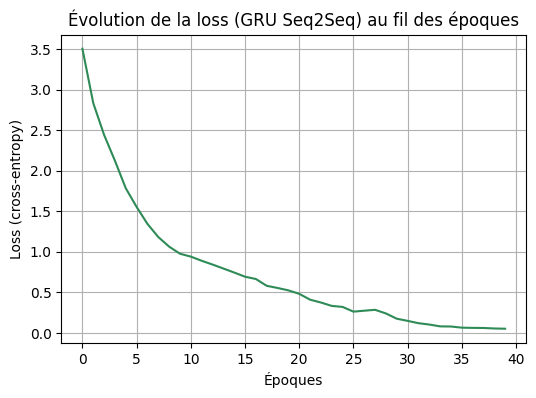

In [7]:
# 5. Visualisation de l'évolution de la loss
plt.figure(figsize=(6, 4))
plt.plot(loss_log, color='seagreen')
plt.title("Évolution de la loss (GRU Seq2Seq) au fil des époques")
plt.xlabel("Époques")
plt.ylabel("Loss (cross-entropy)")
plt.grid(True)
plt.show()


## 1. Objectifs du TP
* Comprendre le fonctionnement du **GRU (Gated Recurrent Unit)**, une simplification du LSTM avec moins de paramètres.
* Implémenter **from scratch** (NumPy uniquement) une architecture **Encodeur-Décodeur GRU** pour la traduction automatique, **sans mécanisme d'attention**.
* Comparer sa dynamique d'apprentissage à celle du RNN et du LSTM sur le **même corpus réel** de traduction anglais → français.

## 2. Concepts Clés Abordés
* **Porte de mise à jour (update gate)** $z_t = \sigma(W_z[h_{t-1}, x_t] + b_z)$ : arbitre entre garder l'ancien état et adopter le nouveau candidat.
* **Porte de reset** $r_t = \sigma(W_r[h_{t-1}, x_t] + b_r)$ : contrôle la part de l'état passé utilisée pour calculer le candidat.
* **État candidat :** $\tilde{h}_t = \tanh(W_h[r_t \odot h_{t-1}, x_t] + b_h)$.
* **Mise à jour finale :** $h_t = (1-z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t$ — une simple interpolation, sans état de cellule séparé contrairement au LSTM.
* **GRU vs LSTM :** le GRU fusionne les portes d'oubli et d'entrée du LSTM en une seule porte $z_t$, et n'a pas de $c_t$ distinct de $h_t$ — moins de paramètres, souvent des performances comparables sur des séquences courtes/moyennes.

## 3. Résultats Obtenus
* **Convergence :** la loss diminue rapidement, avec une dynamique généralement proche de celle du LSTM (comparer les courbes des trois modèles récurrents).
* **Traduction :** les traductions générées sur le corpus d'entraînement sont cohérentes, avec un temps d'entraînement légèrement plus rapide que le LSTM (moins de matrices de poids à mettre à jour).

## 4. Conclusion & Limites
Le GRU offre un bon compromis entre la simplicité du RNN vanille et la puissance du LSTM, avec **2 portes au lieu de 3** et donc moins de paramètres à apprendre, tout en conservant un mécanisme de gating qui atténue le problème du gradient évanescent. Comme le RNN et le LSTM, il reste néanmoins **sans self-attention** : la phrase source est toujours résumée dans un unique vecteur d'état transmis au décodeur, ce qui limite le passage à l'échelle sur des phrases longues. C'est cette limite que lève le **Transformer**, grâce à la self-attention qui donne au décodeur un accès direct et pondéré à **tous** les mots de la phrase source.